# 📐 Dimensionality Reduction
### PCA, t-SNE, UMAP, LDA — From Math to Code to Interviews

---

**What you'll learn:**
1. Why dimensionality reduction matters (curse of dimensionality)
2. PCA — full mathematical derivation, step by step from scratch
3. Kernel PCA — handling nonlinear data
4. LDA — supervised dimensionality reduction
5. t-SNE — neighbor-preserving embeddings for visualization
6. UMAP — faster, better structure preservation
7. When to use which — and how to answer interview questions

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris, load_digits, make_swiss_roll, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#FFC107', '#9C27B0', '#00BCD4']

print('✅ All imports ready.')

✅ All imports ready.


---
# Part 1: Why Reduce Dimensions?
---

## 1.1 The Curse of Dimensionality

As the number of features grows:

- **Data becomes sparse.** In high dimensions, all points are roughly equidistant from each other. Distance-based methods (KNN, clustering) break down.
- **Volume grows exponentially.** To maintain the same data density in $d$ dimensions, you need $n^d$ samples. 10 points per feature × 100 features = $10^{100}$ points needed.
- **Overfitting risk increases.** More features = more parameters = easier to memorize noise.
- **Computation slows down.** Training time often scales with feature count.

### Why do distances break down?

Imagine 5 people described by 2 features (height, weight). You can plot them in 2D — some people are clearly close (similar) and others are far apart (different). Distances are meaningful.

Now describe those same 5 people with 1000 features (height, weight, shoe size, blood pressure, income, ...). The Euclidean distance between any two people is:

$$d(A, B) = \sqrt{(x_1^A - x_1^B)^2 + (x_2^A - x_2^B)^2 + \cdots + (x_{1000}^A - x_{1000}^B)^2}$$

You're summing 1000 squared differences. By the law of large numbers, this sum averages out — every pair ends up with a similar total. Person A is distance 47.3 from B, 47.8 from C, 48.1 from D...

So if you ask "who is most similar to A?", the answer is basically a coin flip. All distances are roughly the same — the concept of "nearest neighbor" becomes meaningless.

The plot below shows this: as dimensions increase, the gap between the closest and farthest point shrinks relative to overall distances. Everything becomes equidistant.

**This is why we reduce dimensions:** get back to a space where distances actually tell you something useful.

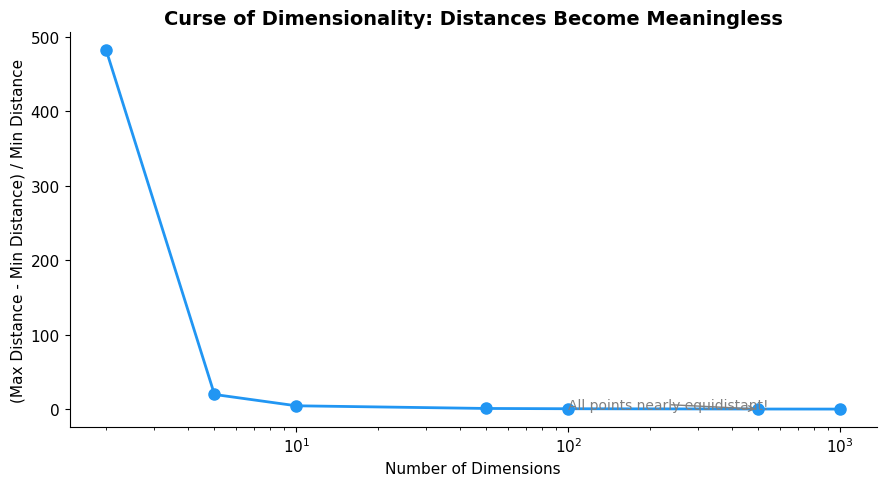

As dimensions increase, the relative gap between the nearest and farthest point shrinks.
This means all pairwise distances converge to roughly the same value.
KNN, clustering, and any distance-based method struggle because
"nearest neighbor" becomes almost arbitrary — everyone is equally far.


In [2]:
# ── Curse of dimensionality: distances converge in high dimensions ──

np.random.seed(42)

dims = [2, 5, 10, 50, 100, 500, 1000]
ratios = []

for d in dims:
    points = np.random.uniform(0, 1, size=(200, d))
    # Compute all pairwise distances
    from sklearn.metrics import pairwise_distances
    dists = pairwise_distances(points).ravel()
    dists = dists[dists > 0]  # Remove self-distances
    ratio = (dists.max() - dists.min()) / dists.min()
    ratios.append(ratio)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dims, ratios, 'o-', color=COLORS[0], lw=2, markersize=8)
ax.set_xlabel('Number of Dimensions')
ax.set_ylabel('(Max Distance - Min Distance) / Min Distance')
ax.set_title('Curse of Dimensionality: Distances Become Meaningless')
ax.set_xscale('log')
ax.annotate('All points nearly equidistant!', xy=(500, ratios[-2]),
            xytext=(100, ratios[-2] + 0.5),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')
plt.tight_layout()
plt.show()

print('As dimensions increase, the relative gap between the nearest and farthest point shrinks.')
print('This means all pairwise distances converge to roughly the same value.')
print('KNN, clustering, and any distance-based method struggle because')
print('"nearest neighbor" becomes almost arbitrary — everyone is equally far.')

## 1.2 Two Families of Methods

| | Feature Selection | Feature Extraction (Dim. Reduction) |
|---|---|---|
| **What it does** | Picks a subset of original features | Creates new features as combinations |
| **Interpretability** | High (original features) | Lower (transformed features) |
| **Examples** | Lasso, mutual information, forward selection | PCA, t-SNE, UMAP, LDA |

This notebook focuses on **feature extraction** — creating new, lower-dimensional representations.

---
# Part 2: Principal Component Analysis (PCA)
---

## 2.1 The Core Idea — No Linear Algebra Needed

Imagine you photograph a 3D object (say, a coffee mug) from different angles. Some angles show you almost everything about the mug's shape — the handle, the rim, the body. Other angles are useless — you just see a circle.

PCA does the same thing with data. Your dataset has many features (dimensions), and PCA finds the **best angle to look at your data** — the viewpoint that shows you the most information with the fewest dimensions.

**What "information" means here:** spread. If you project your data onto a line and all the points land on top of each other, that line tells you nothing — all points look the same. But if the points spread out along the line, you can distinguish them. PCA finds the line (or plane, or hyperplane) where the data spreads out the most.

### A concrete example

Imagine you have data on students with two features: hours studied and exam score. These are highly correlated — more study → higher score. If you plot them, the data forms a tilted cloud:

- **Along the cloud** (the tilted direction): students are spread out. This direction captures the main pattern: "overall performance." This is PC1.
- **Across the cloud** (perpendicular to it): very little spread. This direction captures just noise/small deviations. This is PC2.

So instead of 2 features, you could describe each student with just 1 number (their position along PC1) and lose very little information. That's dimensionality reduction.

### What PCA actually computes

1. **Center the data** — shift everything so the mean is at the origin
2. **Find the direction of maximum spread** — this becomes PC1
3. **Find the next direction of maximum spread, perpendicular to PC1** — this becomes PC2
4. **Repeat** — each new PC is perpendicular to all previous ones
5. **Keep only the top $k$ PCs** — drop the rest (they carry little information)

The "direction of maximum spread" is formally called the direction of maximum variance. The math below shows how to find it — but the intuition is just: **find the best angle to view your data**.

---

## 2.2 The Math — Step by Step

Now let's formalize "find the direction of maximum spread."

Given data matrix $X \in \mathbb{R}^{n \times p}$ ($n$ samples, $p$ features):

### Step 1: Center the data
$$X_c = X - \bar{X}$$
Subtract the mean of each feature. This ensures PC1 passes through the data center.

### Step 2: Compute the covariance matrix
$$C = \frac{1}{n-1} X_c^T X_c \in \mathbb{R}^{p \times p}$$

This matrix summarizes how every pair of features moves together. $C_{ij}$ measures how features $i$ and $j$ co-vary. Diagonal entries = variances. Off-diagonal entries = covariances.

### Step 3: Eigendecomposition

This is where eigenvectors come in. Think of it this way:

- The **covariance matrix** encodes all the "spread" information of the data
- **Eigenvectors** are the special directions where this spread is simplest — they point exactly along the axes of the data's elliptical shape
- **Eigenvalues** tell you how much spread exists along each eigenvector

Formally:
$$C v_k = \lambda_k v_k$$

- $v_k$ = eigenvector = direction of the $k$-th principal component
- $\lambda_k$ = eigenvalue = amount of variance (spread) along that direction

If you haven't seen eigendecomposition before: you're essentially asking the covariance matrix "what are your natural axes?" The eigenvectors are the answer, and the eigenvalues tell you how important each axis is.

### Step 4: Sort and project
Sort eigenvectors by eigenvalue (largest first). The first eigenvector = most spread = PC1. Pick the top $k$ eigenvectors to form matrix $W \in \mathbb{R}^{p \times k}$:

$$Z = X_c \cdot W \in \mathbb{R}^{n \times k}$$

$Z$ is your reduced-dimension data. Each row is a sample described by $k$ new features instead of $p$ original ones.

### Variance explained
$$\text{Variance explained by PC}_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$$

This tells you what fraction of the total information each component captures. If PC1 explains 90% of variance, you can drop everything else and keep 90% of the information.

In [3]:
# ── PCA from scratch ──

class PCAFromScratch:
    """PCA implemented from scratch for educational purposes."""
    
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None      # Eigenvectors (principal directions)
        self.eigenvalues = None
        self.mean = None
        self.explained_variance_ratio = None
    
    def fit(self, X):
        # Step 1: Center the data
        self.mean = X.mean(axis=0)
        X_centered = X - self.mean
        
        # Step 2: Covariance matrix
        n = X.shape[0]
        cov_matrix = (X_centered.T @ X_centered) / (n - 1)
        
        # Step 3: Eigendecomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # Sort by eigenvalue (descending)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]
        
        # Store top k components
        self.eigenvalues = eigenvalues
        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio = eigenvalues / eigenvalues.sum()
        
        return self
    
    def transform(self, X):
        # Step 4: Project onto principal components
        X_centered = X - self.mean
        return X_centered @ self.components
    
    def inverse_transform(self, Z):
        # Reconstruct back to original space
        return Z @ self.components.T + self.mean

# Test on Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Standardize first (important for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# Our PCA
pca_scratch = PCAFromScratch(n_components=2).fit(X_scaled)
Z_scratch = pca_scratch.transform(X_scaled)

# Sklearn PCA for comparison
pca_sklearn = PCA(n_components=2).fit(X_scaled)
Z_sklearn = pca_sklearn.transform(X_scaled)

print('Our eigenvalues:    ', pca_scratch.eigenvalues[:4].round(4))
print('Sklearn eigenvalues:', pca_sklearn.explained_variance_[:4].round(4))
print()
print('Variance explained (ours):   ', pca_scratch.explained_variance_ratio[:4].round(4))
print('Variance explained (sklearn):', pca_sklearn.explained_variance_ratio_.round(4))
print()
print('Max difference between projections:',
      np.max(np.abs(np.abs(Z_scratch) - np.abs(Z_sklearn))).round(10))
print('\n✅ Our implementation matches sklearn!')

Our eigenvalues:     [2.9381 0.9202 0.1477 0.0209]
Sklearn eigenvalues: [2.9381 0.9202]

Variance explained (ours):    [0.7296 0.2285 0.0367 0.0052]
Variance explained (sklearn): [0.7296 0.2285]

Max difference between projections: 0.0

✅ Our implementation matches sklearn!


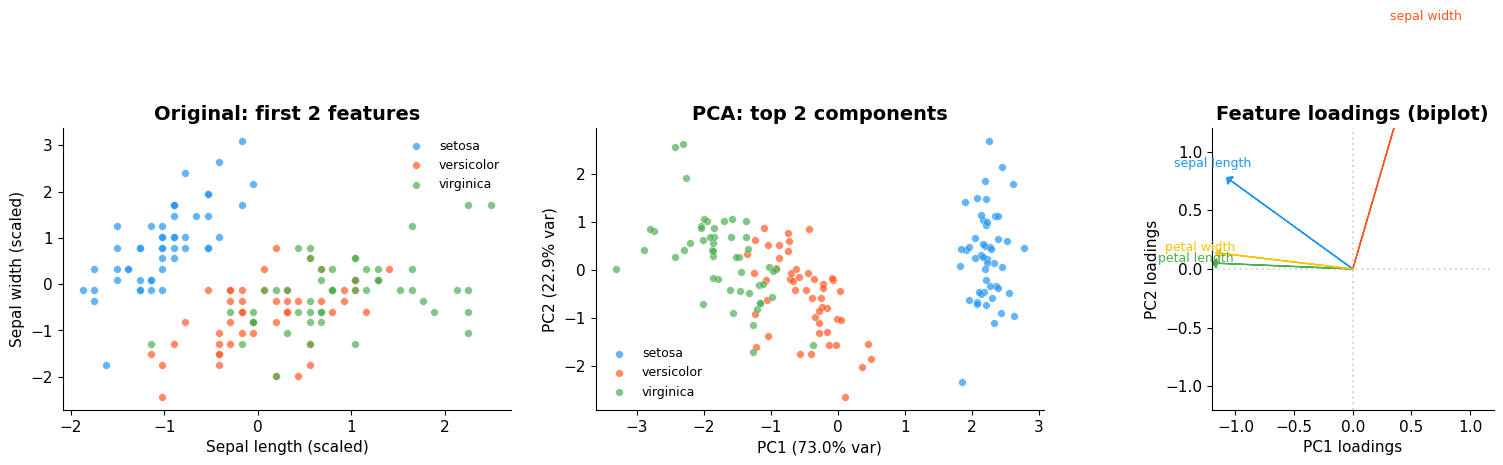

PCA separates the classes much better than raw features!
The biplot shows how original features contribute to each PC.
Petal length & width point in similar directions → they are correlated.


In [4]:
# ── Visualize PCA on Iris: what the principal components look like ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Original 2D (first two features)
ax = axes[0]
for label, color, name in zip([0, 1, 2], COLORS[:3], iris.target_names):
    mask = y_iris == label
    ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], c=color, s=30,
              label=name, edgecolors='white', linewidths=0.3, alpha=0.7)
ax.set_xlabel('Sepal length (scaled)')
ax.set_ylabel('Sepal width (scaled)')
ax.set_title('Original: first 2 features')
ax.legend(frameon=False, fontsize=9)

# PCA 2D
ax = axes[1]
for label, color, name in zip([0, 1, 2], COLORS[:3], iris.target_names):
    mask = y_iris == label
    ax.scatter(Z_scratch[mask, 0], Z_scratch[mask, 1], c=color, s=30,
              label=name, edgecolors='white', linewidths=0.3, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca_scratch.explained_variance_ratio[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca_scratch.explained_variance_ratio[1]:.1%} var)')
ax.set_title('PCA: top 2 components')
ax.legend(frameon=False, fontsize=9)

# Component loadings
ax = axes[2]
loadings = pca_scratch.components
for i, name in enumerate(iris.feature_names):
    ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
             head_width=0.08, head_length=0.04, fc=COLORS[i], ec=COLORS[i])
    ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, name.replace(' (cm)', ''),
            fontsize=9, ha='center', color=COLORS[i])
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('PC1 loadings')
ax.set_ylabel('PC2 loadings')
ax.set_title('Feature loadings (biplot)')
ax.axhline(0, color='gray', ls=':', alpha=0.3)
ax.axvline(0, color='gray', ls=':', alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print('PCA separates the classes much better than raw features!')
print('The biplot shows how original features contribute to each PC.')
print('Petal length & width point in similar directions → they are correlated.')

## 2.3 Geometric Intuition

PCA finds the direction where the data is most spread out (PC1), then the next most spread direction **orthogonal** to PC1 (PC2), and so on.

Let's see this visually in 2D — PCA finds the axes of an ellipse.

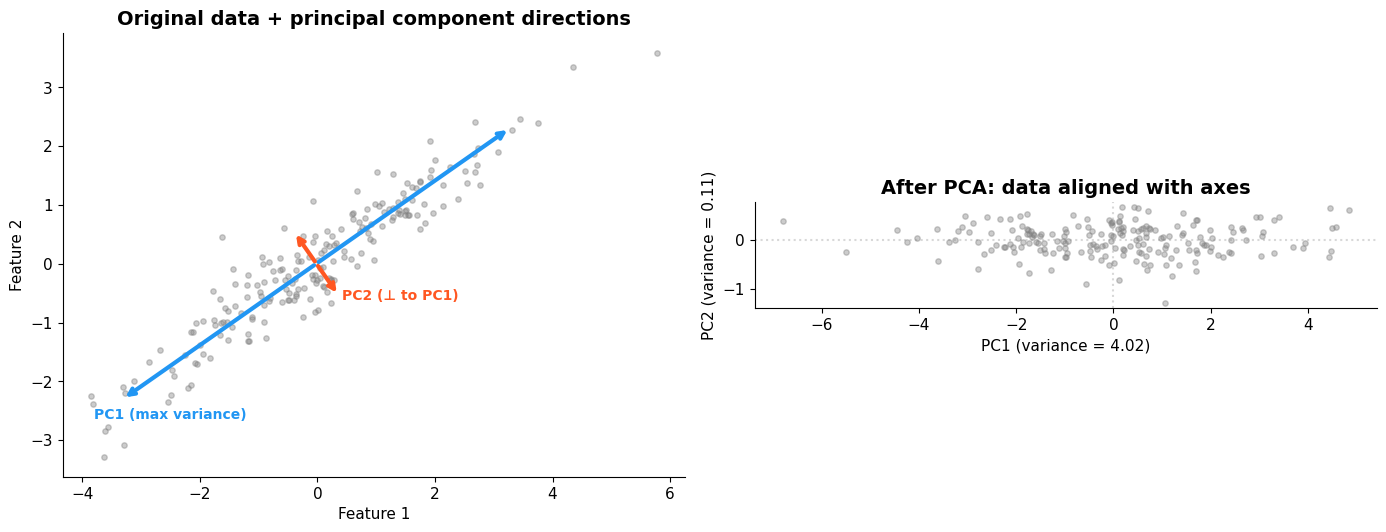

PCA rotates the data so the axes align with maximum variance directions.
The covariance matrix becomes diagonal after the transformation.

Covariance of original: off-diag = 1.841
Covariance after PCA:   off-diag = 0.000000  (≈ 0!)


In [5]:
# ── Geometric intuition: PCA finds axes of the data ellipse ──

np.random.seed(42)
# Create correlated 2D data
mean = [0, 0]
cov = [[3, 2], [2, 1.5]]
X_2d = np.random.multivariate_normal(mean, cov, 200)

pca_2d = PCAFromScratch(n_components=2).fit(X_2d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Original data with PC directions
ax = axes[0]
ax.scatter(X_2d[:, 0], X_2d[:, 1], c='gray', s=15, alpha=0.4)

origin = X_2d.mean(axis=0)
for i, (ev, color, label) in enumerate(zip(
    pca_2d.eigenvalues[:2], [COLORS[0], COLORS[1]],
    ['PC1 (max variance)', 'PC2 (⊥ to PC1)'])):
    vec = pca_2d.components[:, i] * np.sqrt(ev) * 2
    ax.annotate('', xy=origin + vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=3))
    ax.annotate('', xy=origin - vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=3))
    ax.text(origin[0] + vec[0]*1.15, origin[1] + vec[1]*1.15,
            label, fontsize=10, color=color, fontweight='bold')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Original data + principal component directions')
ax.set_aspect('equal')

# Right: Projected (rotated) data
Z_2d = pca_2d.transform(X_2d)
ax = axes[1]
ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c='gray', s=15, alpha=0.4)
ax.set_xlabel(f'PC1 (variance = {pca_2d.eigenvalues[0]:.2f})')
ax.set_ylabel(f'PC2 (variance = {pca_2d.eigenvalues[1]:.2f})')
ax.set_title('After PCA: data aligned with axes')
ax.axhline(0, color='gray', ls=':', alpha=0.3)
ax.axvline(0, color='gray', ls=':', alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print('PCA rotates the data so the axes align with maximum variance directions.')
print('The covariance matrix becomes diagonal after the transformation.')
print(f'\nCovariance of original: off-diag = {np.cov(X_2d.T)[0,1]:.3f}')
print(f'Covariance after PCA:   off-diag = {np.cov(Z_2d.T)[0,1]:.6f}  (≈ 0!)')

## 2.4 How Many Components to Keep?

Three common strategies:

1. **Explained variance threshold** — Keep enough PCs to explain 90-95% of total variance
2. **Elbow method** — Plot explained variance vs. number of PCs, look for the "elbow"
3. **Kaiser criterion** — Keep PCs with eigenvalue > 1 (for standardized data)

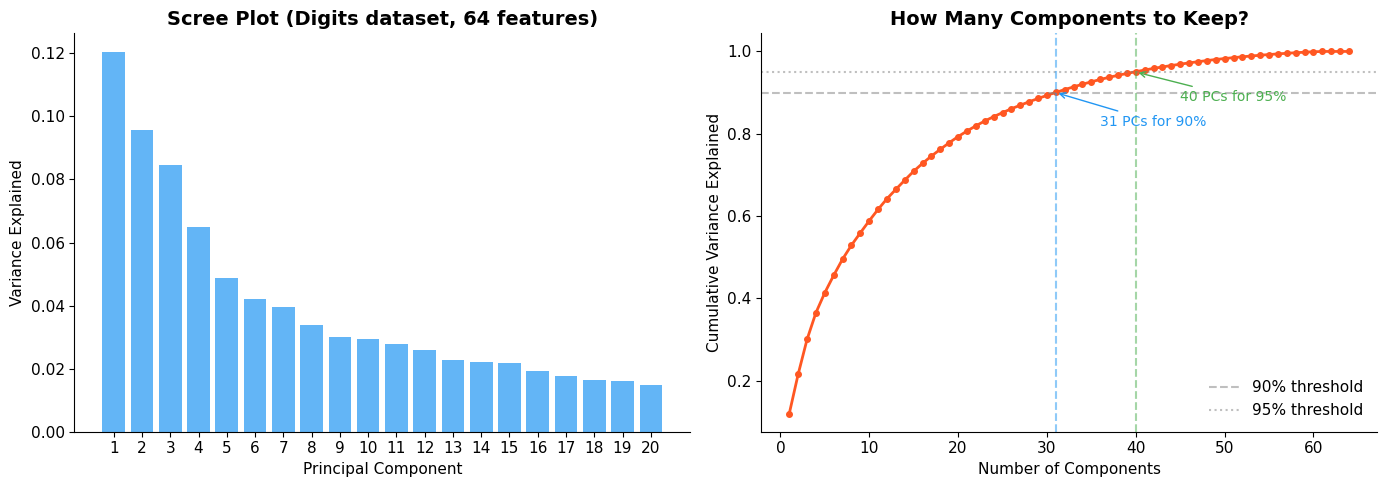

64 original features → 31 PCs capture 90% of variance
64 original features → 40 PCs capture 95% of variance
That's a 2.1x and 1.6x reduction!


In [6]:
# ── Scree plot and cumulative variance on a real dataset ──

digits = load_digits()
X_digits = StandardScaler().fit_transform(digits.data)  # 64 features (8x8 pixels)

pca_full = PCA().fit(X_digits)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax = axes[0]
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20],
       color=COLORS[0], alpha=0.7)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax.set_title('Scree Plot (Digits dataset, 64 features)')
ax.set_xticks(range(1, 21))

# Cumulative variance
ax = axes[1]
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax.plot(range(1, 65), cumvar, 'o-', color=COLORS[1], lw=2, markersize=4)
ax.axhline(0.90, color='gray', ls='--', alpha=0.5, label='90% threshold')
ax.axhline(0.95, color='gray', ls=':', alpha=0.5, label='95% threshold')

# Find number of components for 90% and 95%
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
ax.axvline(n_90, color=COLORS[0], ls='--', alpha=0.5)
ax.axvline(n_95, color=COLORS[2], ls='--', alpha=0.5)
ax.annotate(f'{n_90} PCs for 90%', xy=(n_90, 0.90),
            xytext=(n_90 + 5, 0.82), fontsize=10, color=COLORS[0],
            arrowprops=dict(arrowstyle='->', color=COLORS[0]))
ax.annotate(f'{n_95} PCs for 95%', xy=(n_95, 0.95),
            xytext=(n_95 + 5, 0.88), fontsize=10, color=COLORS[2],
            arrowprops=dict(arrowstyle='->', color=COLORS[2]))

ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('How Many Components to Keep?')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f'64 original features → {n_90} PCs capture 90% of variance')
print(f'64 original features → {n_95} PCs capture 95% of variance')
print(f'That\'s a {64/n_90:.1f}x and {64/n_95:.1f}x reduction!')

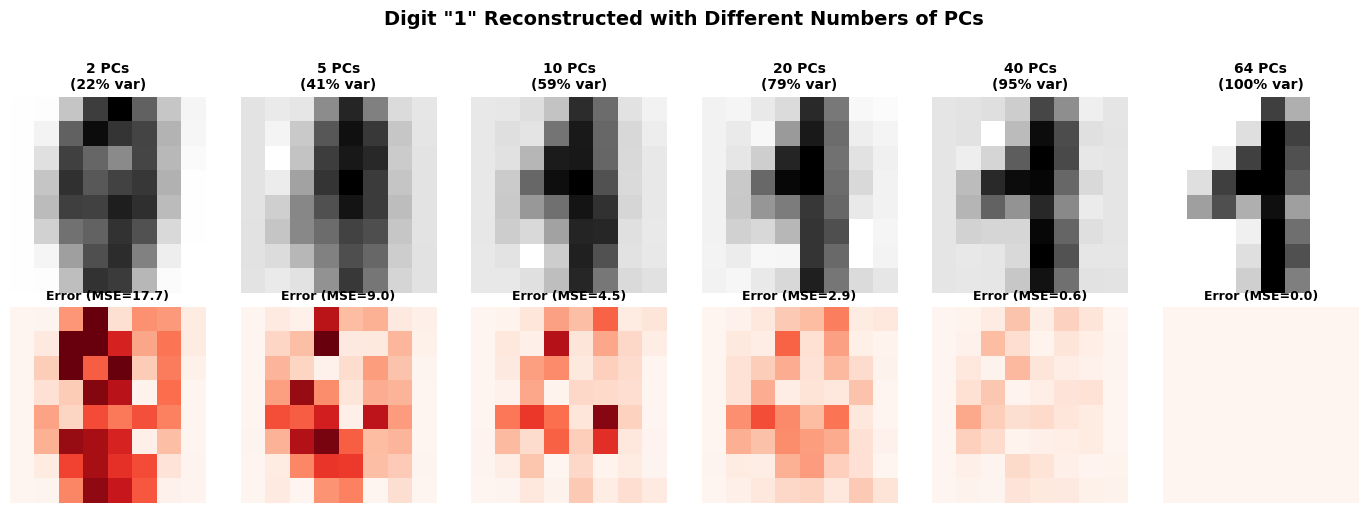

With just 10 PCs (from 64 features), the digit is clearly recognizable!
This is the power of PCA: most of the information is in a few directions.


In [7]:
# ── Reconstruction: what information is lost? ──

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

# Pick a sample digit
sample_idx = 42
original = digits.data[sample_idx].reshape(8, 8)

n_components_list = [2, 5, 10, 20, 40, 64]

for i, n_comp in enumerate(n_components_list):
    pca_k = PCA(n_components=n_comp)
    X_proj = pca_k.fit_transform(X_digits)
    X_recon = pca_k.inverse_transform(X_proj)
    # Undo the StandardScaler
    scaler_d = StandardScaler().fit(digits.data)
    X_recon_orig = scaler_d.inverse_transform(X_recon)
    recon_img = X_recon_orig[sample_idx].reshape(8, 8)
    
    # Reconstructed
    axes[0, i].imshow(recon_img, cmap='gray_r', interpolation='nearest')
    axes[0, i].set_title(f'{n_comp} PCs\n({pca_k.explained_variance_ratio_.sum():.0%} var)', fontsize=10)
    axes[0, i].axis('off')
    
    # Error
    error = np.abs(original - recon_img)
    axes[1, i].imshow(error, cmap='Reds', interpolation='nearest', vmin=0, vmax=8)
    axes[1, i].set_title(f'Error (MSE={np.mean(error**2):.1f})', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Reconstructed', fontsize=11)
axes[1, 0].set_ylabel('Error', fontsize=11)

fig.suptitle(f'Digit "{digits.target[sample_idx]}" Reconstructed with Different Numbers of PCs',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('With just 10 PCs (from 64 features), the digit is clearly recognizable!')
print('This is the power of PCA: most of the information is in a few directions.')

## 2.5 PCA via SVD (How sklearn Actually Does It)

Computing the full covariance matrix $X^T X$ is expensive for high-dimensional data ($O(p^2 n)$).  
Instead, sklearn uses **Singular Value Decomposition (SVD)**:

$$X_c = U \Sigma V^T$$

where:
- $U \in \mathbb{R}^{n \times n}$ = left singular vectors
- $\Sigma \in \mathbb{R}^{n \times p}$ = diagonal matrix of singular values
- $V \in \mathbb{R}^{p \times p}$ = right singular vectors = **the principal components**

The relationship: eigenvalues of $C$ = $\frac{\sigma_k^2}{n-1}$ (squared singular values, scaled).

**Why SVD?**
- Numerically more stable than eigendecomposition of $X^T X$
- Can use truncated SVD (only compute top $k$ components) → much faster
- Works even when $p > n$ (more features than samples)

In [8]:
# ── Verify: SVD and eigendecomposition give the same result ──

X_c = X_scaled - X_scaled.mean(axis=0)

# Method 1: Eigendecomposition of covariance matrix
cov = (X_c.T @ X_c) / (len(X_c) - 1)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Method 2: SVD
U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
eigenvalues_svd = s**2 / (len(X_c) - 1)

print('Eigenvalues from covariance:', eigenvalues.round(4))
print('Eigenvalues from SVD:       ', eigenvalues_svd.round(4))
print()
print('The results are identical (up to numerical precision).')
print('SVD is preferred because it avoids explicitly computing X^T X.')

Eigenvalues from covariance: [2.9381 0.9202 0.1477 0.0209]
Eigenvalues from SVD:        [2.9381 0.9202 0.1477 0.0209]

The results are identical (up to numerical precision).
SVD is preferred because it avoids explicitly computing X^T X.


## 2.6 Important: Scaling Before PCA

PCA finds directions of **maximum variance**. If features have different scales, the feature with the largest scale will dominate PC1 — not because it's more informative, but because its numbers are bigger.

**Always standardize before PCA** (zero mean, unit variance) unless your features are already on the same scale.

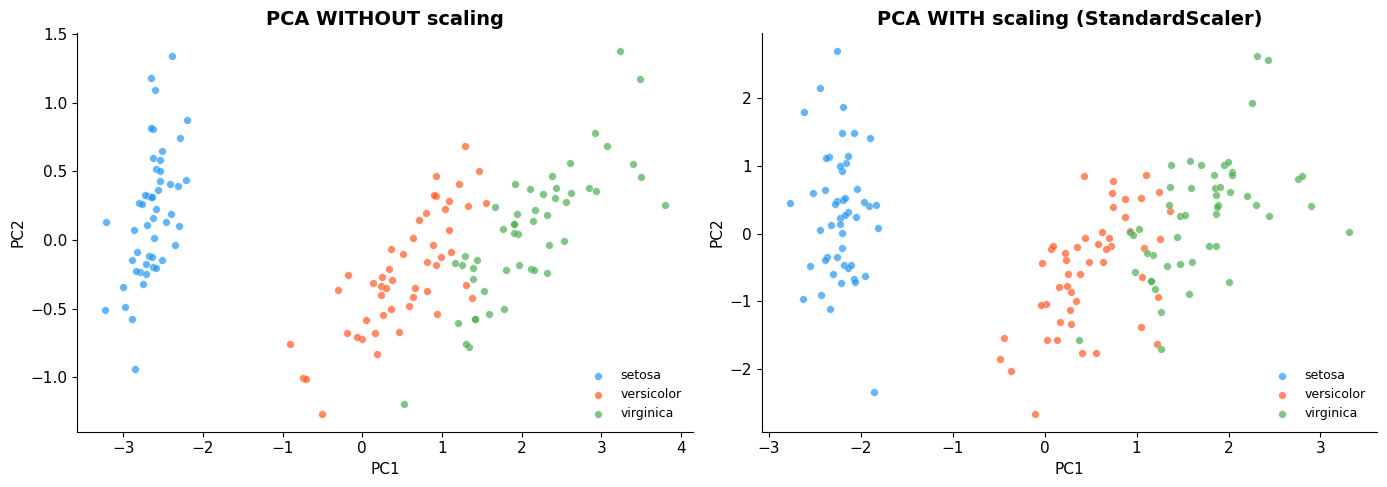

Without scaling, features with larger magnitudes dominate the PCs.
With scaling, all features contribute equally based on their variance patterns.

💡 Interview tip: "Do you need to scale before PCA?" → Almost always yes.


In [9]:
# ── Effect of scaling ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(
    axes, [iris.data, StandardScaler().fit_transform(iris.data)],
    ['PCA WITHOUT scaling', 'PCA WITH scaling (StandardScaler)']):
    
    Z = PCA(n_components=2).fit_transform(data)
    for label, color, name in zip([0, 1, 2], COLORS[:3], iris.target_names):
        mask = y_iris == label
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, s=30,
                  label=name, edgecolors='white', linewidths=0.3, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print('Without scaling, features with larger magnitudes dominate the PCs.')
print('With scaling, all features contribute equally based on their variance patterns.')
print('\n💡 Interview tip: "Do you need to scale before PCA?" → Almost always yes.')

## 2.7 PCA Limitations

PCA only captures **linear** relationships. If the data lies on a curved manifold, PCA can't unfold it.

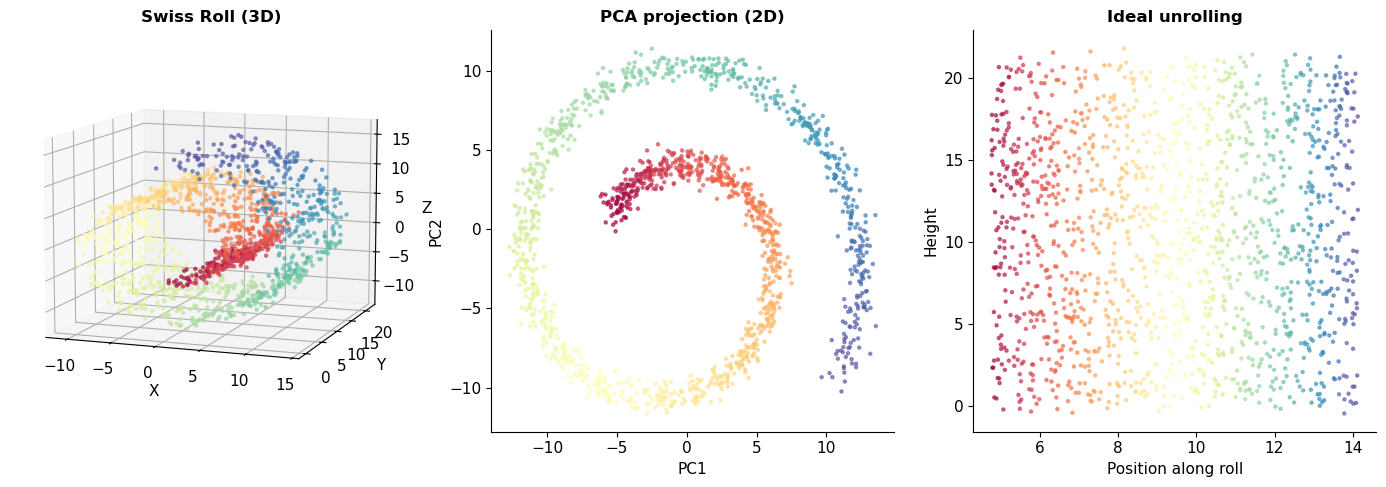

PCA just squashes the roll flat — nearby colors get mixed together.
We need nonlinear methods to "unroll" it properly.


In [10]:

# ── PCA fails on nonlinear data ──

# Swiss Roll: a 2D surface curved in 3D
X_swiss, color_swiss = make_swiss_roll(n_samples=1500, noise=0.5, random_state=42)

fig = plt.figure(figsize=(14, 5))

# 3D view
ax = fig.add_subplot(131, projection='3d')
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2],
           c=color_swiss, cmap='Spectral', s=5, alpha=0.6)
ax.set_title('Swiss Roll (3D)', fontsize=12)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(10, -70)

# PCA projection
ax = fig.add_subplot(132)
Z_pca_swiss = PCA(n_components=2).fit_transform(X_swiss)
ax.scatter(Z_pca_swiss[:, 0], Z_pca_swiss[:, 1],
           c=color_swiss, cmap='Spectral', s=5, alpha=0.6)
ax.set_title('PCA projection (2D)', fontsize=12)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# What we WANT: unrolled
ax = fig.add_subplot(133)
ax.scatter(color_swiss, X_swiss[:, 1],
           c=color_swiss, cmap='Spectral', s=5, alpha=0.6)
ax.set_title('Ideal unrolling', fontsize=12)
ax.set_xlabel('Position along roll')
ax.set_ylabel('Height')

plt.tight_layout()
plt.show()

print('PCA just squashes the roll flat — nearby colors get mixed together.')
print('We need nonlinear methods to "unroll" it properly.')

---
# Part 3: Kernel PCA
---

## 3.1 The Idea

Same as PCA, but first map data to a **higher-dimensional feature space** using a kernel function, then do PCA there.

The kernel trick: we never actually compute the mapping $\phi(x)$. Instead, we work with the **kernel matrix** $K_{ij} = \kappa(x_i, x_j)$ which gives dot products in the feature space.

Common kernels:
- **RBF (Gaussian):** $\kappa(x, y) = \exp\left(-\gamma \|x - y\|^2\right)$
- **Polynomial:** $\kappa(x, y) = (x^T y + c)^d$

### The Math

Instead of eigendecomposing the covariance matrix $X^T X$, we eigendecompose the **centered kernel matrix**:

$$\tilde{K} = K - \mathbf{1}_n K - K \mathbf{1}_n + \mathbf{1}_n K \mathbf{1}_n$$

where $\mathbf{1}_n = \frac{1}{n} \mathbf{1}\mathbf{1}^T$ is the centering matrix.

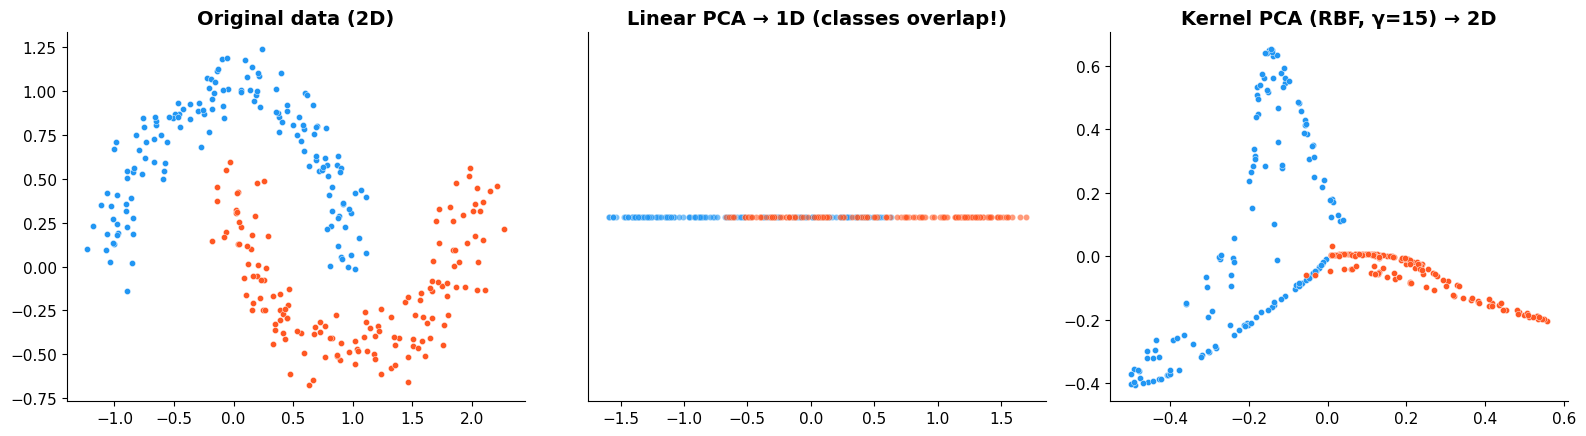

Linear PCA squashes the moons together — can't separate them in 1D.
Kernel PCA unfolds the nonlinear structure — classes become separable!


In [11]:
# ── Kernel PCA on nonlinear data ──

# Make moons — clearly nonlinear
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Original
ax = axes[0]
for label, color in zip([0, 1], COLORS[:2]):
    mask = y_moons == label
    ax.scatter(X_moons[mask, 0], X_moons[mask, 1], c=color, s=20,
              edgecolors='white', linewidths=0.3)
ax.set_title('Original data (2D)')

# Linear PCA
ax = axes[1]
Z_lin = PCA(n_components=1).fit_transform(X_moons)
for label, color in zip([0, 1], COLORS[:2]):
    mask = y_moons == label
    ax.scatter(Z_lin[mask], np.zeros(mask.sum()), c=color, s=20,
              edgecolors='white', linewidths=0.3, alpha=0.6)
ax.set_title('Linear PCA → 1D (classes overlap!)')
ax.set_yticks([])

# Kernel PCA with RBF
ax = axes[2]
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15)
Z_kpca = kpca.fit_transform(X_moons)
for label, color in zip([0, 1], COLORS[:2]):
    mask = y_moons == label
    ax.scatter(Z_kpca[mask, 0], Z_kpca[mask, 1], c=color, s=20,
              edgecolors='white', linewidths=0.3)
ax.set_title('Kernel PCA (RBF, γ=15) → 2D')

plt.tight_layout()
plt.show()

print('Linear PCA squashes the moons together — can\'t separate them in 1D.')
print('Kernel PCA unfolds the nonlinear structure — classes become separable!')

---
# Part 4: Linear Discriminant Analysis (LDA)
---

## 4.1 PCA vs LDA — The Key Difference

| | PCA | LDA |
|---|---|---|
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximize total variance | Maximize class separability |
| **Uses labels?** | No | Yes |
| **Max components** | $\min(n, p)$ | $K - 1$ (number of classes - 1) |

## 4.2 The Math

LDA maximizes the ratio of **between-class scatter** to **within-class scatter**.

**Within-class scatter matrix:**

$$S_W = \sum_{k=1}^{K} \sum_{x \in C_k} (x - \mu_k)(x - \mu_k)^T$$

**Between-class scatter matrix:**

$$S_B = \sum_{k=1}^{K} n_k (\mu_k - \mu)(\mu_k - \mu)^T$$

**Objective** — find $w$ that maximizes:

$$J(w) = \frac{w^T S_B w}{w^T S_W w}$$

Solution: eigenvectors of $S_W^{-1} S_B$, sorted by eigenvalue.

**Intuition:** LDA finds directions where the class means are far apart ($S_B$ large) and the within-class spread is small ($S_W$ small).

In [12]:
# ── LDA from scratch ──

class LDAFromScratch:
    """Linear Discriminant Analysis from scratch."""
    
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.eigenvalues = None
        self.mean = None
    
    def fit(self, X, y):
        n, p = X.shape
        classes = np.unique(y)
        self.mean = X.mean(axis=0)
        
        # Within-class scatter
        S_W = np.zeros((p, p))
        for c in classes:
            X_c = X[y == c]
            mean_c = X_c.mean(axis=0)
            diff = X_c - mean_c
            S_W += diff.T @ diff
        
        # Between-class scatter
        S_B = np.zeros((p, p))
        for c in classes:
            n_c = (y == c).sum()
            mean_c = X[y == c].mean(axis=0)
            diff = (mean_c - self.mean).reshape(-1, 1)
            S_B += n_c * (diff @ diff.T)
        
        # Solve generalized eigenvalue problem
        eigenvalues, eigenvectors = np.linalg.eigh(np.linalg.inv(S_W) @ S_B)
        
        # Sort descending
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[idx]
        self.components = eigenvectors[:, idx[:self.n_components]]
        
        return self
    
    def transform(self, X):
        return (X - self.mean) @ self.components

# Compare PCA vs LDA on Iris
lda_scratch = LDAFromScratch(n_components=2).fit(X_scaled, y_iris)
Z_lda = lda_scratch.transform(X_scaled)

# Sklearn LDA
lda_sklearn = LinearDiscriminantAnalysis(n_components=2).fit(X_scaled, y_iris)
Z_lda_sk = lda_sklearn.transform(X_scaled)

print('Our LDA eigenvalues:', lda_scratch.eigenvalues[:3].round(4))
print('\n✅ LDA implementation complete!')

Our LDA eigenvalues: [43.098   4.1645 -1.5353]

✅ LDA implementation complete!


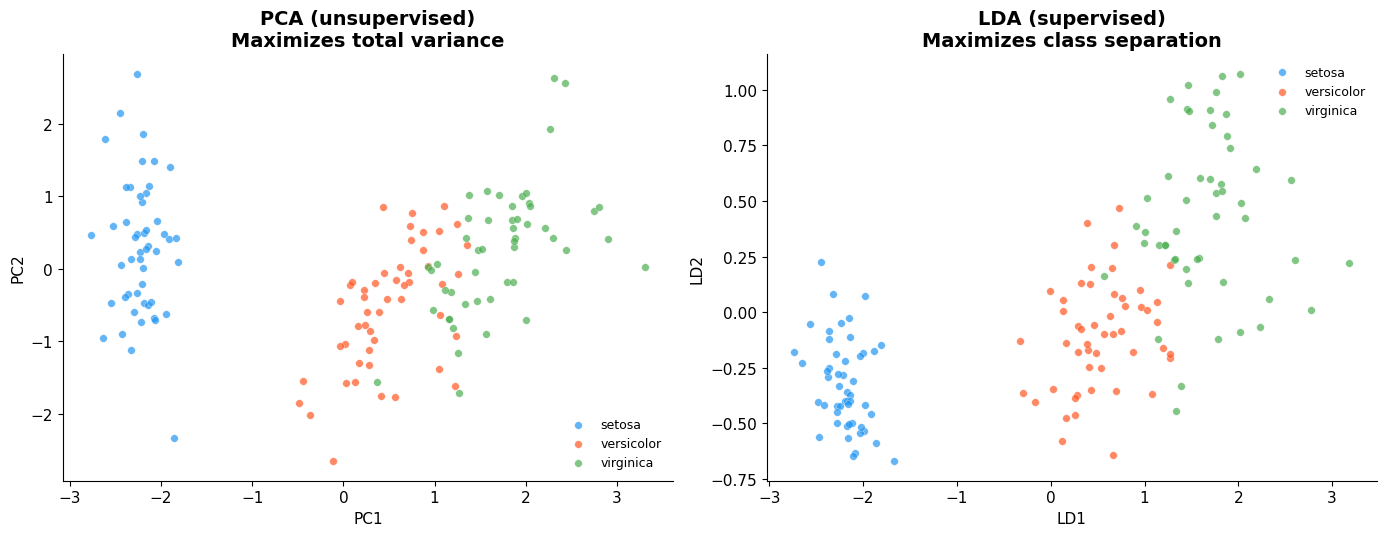

PCA finds directions of max variance — ignores class labels.
LDA finds directions that best separate classes — uses labels.
LDA gives tighter, more separated clusters when classes are known.

💡 For 3 classes, LDA gives at most K-1 = 2 components.


In [13]:

# ── PCA vs LDA side by side ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# PCA
ax = axes[0]
Z_pca = PCA(n_components=2).fit_transform(X_scaled)
for label, color, name in zip([0, 1, 2], COLORS[:3], iris.target_names):
    mask = y_iris == label
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1], c=color, s=30,
              label=name, edgecolors='white', linewidths=0.3, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA (unsupervised)\nMaximizes total variance')
ax.legend(frameon=False, fontsize=9)

# LDA
ax = axes[1]
for label, color, name in zip([0, 1, 2], COLORS[:3], iris.target_names):
    mask = y_iris == label
    ax.scatter(Z_lda[mask, 0], Z_lda[mask, 1], c=color, s=30,
              label=name, edgecolors='white', linewidths=0.3, alpha=0.7)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('LDA (supervised)\nMaximizes class separation')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print('PCA finds directions of max variance — ignores class labels.')
print('LDA finds directions that best separate classes — uses labels.')
print('LDA gives tighter, more separated clusters when classes are known.')
print(f'\n💡 For 3 classes, LDA gives at most K-1 = {len(iris.target_names)-1} components.')

In [14]:
# ── Classification accuracy: PCA vs LDA as preprocessing ──

results = []
for name, transformer in [
    ('No reduction (4 features)', None),
    ('PCA (2 components)', PCA(n_components=2)),
    ('LDA (2 components)', LinearDiscriminantAnalysis(n_components=2)),
]:
    if transformer:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('reduce', transformer),
            ('clf', LogisticRegression())
        ])
    else:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression())
        ])
    
    cv = cross_val_score(pipe, iris.data, iris.target, cv=5, scoring='accuracy')
    results.append({'Method': name, 'CV Accuracy': f'{cv.mean():.4f} ± {cv.std():.4f}'})

print(pd.DataFrame(results).to_string(index=False))
print('\nLDA preserves the class-relevant information even with fewer dimensions!')

                   Method     CV Accuracy
No reduction (4 features) 0.9600 ± 0.0389
       PCA (2 components) 0.9133 ± 0.0542
       LDA (2 components) 0.9800 ± 0.0267

LDA preserves the class-relevant information even with fewer dimensions!


---
# Part 5: t-SNE (t-Distributed Stochastic Neighbor Embedding)
---

## 5.1 The Idea

t-SNE is a **nonlinear** method designed for **visualization** (reducing to 2D or 3D).

Core idea: preserve **neighborhood structure** — points that are close in high dimensions should stay close in low dimensions.

## 5.2 The Math

### Step 1: High-dimensional similarities

For each pair $(i, j)$, compute a conditional probability that $i$ would pick $j$ as its neighbor:

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

Symmetrize: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$

$\sigma_i$ is chosen so each point has a fixed **perplexity** (roughly: number of effective neighbors).

### Step 2: Low-dimensional similarities

In the embedding space, use a **Student-t distribution** (with 1 degree of freedom = Cauchy):

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}$$

### Step 3: Minimize KL divergence

$$\text{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Use gradient descent to move the $y_i$ points until $Q \approx P$.

### Why t-distribution in low dimensions?

The **crowding problem**: In high dimensions, a point can have many equidistant neighbors. In 2D, there's not enough room. The t-distribution has heavier tails than a Gaussian, allowing moderate distances in high-D to become larger in low-D without pulling distant points too close.

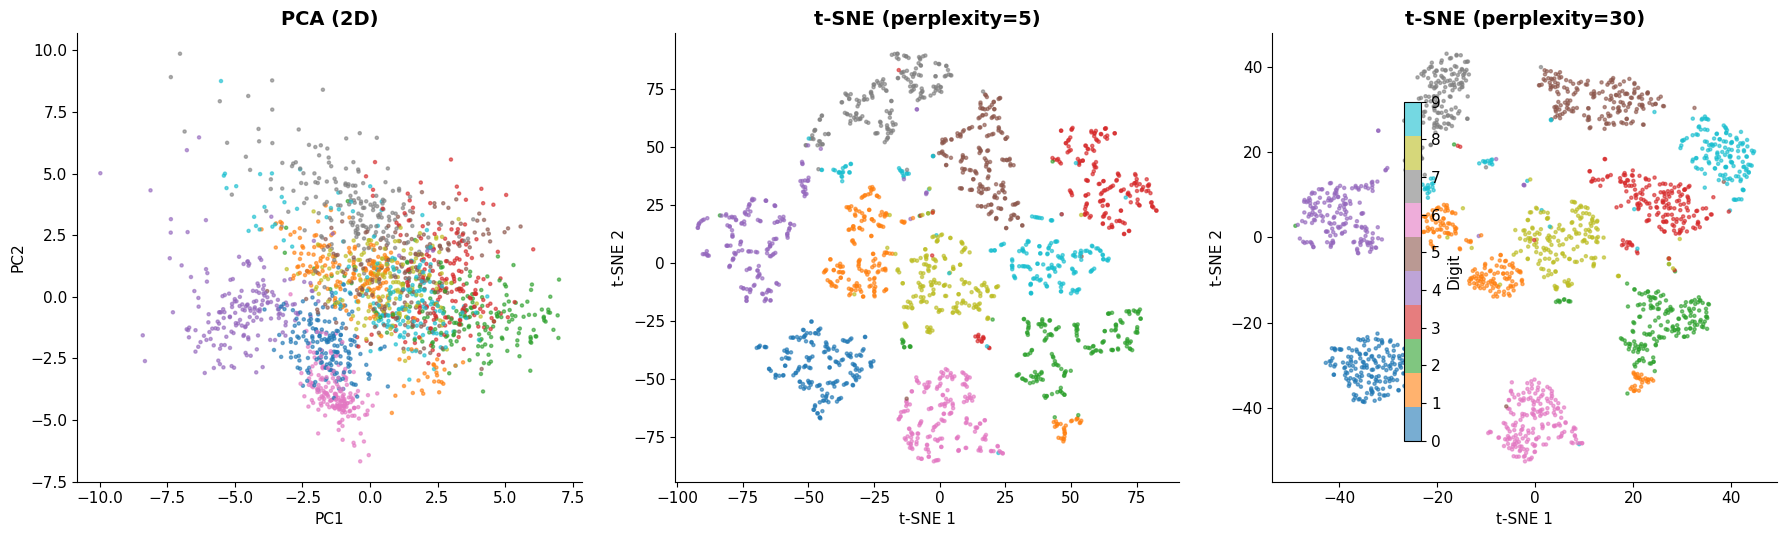

PCA: some overlap between digit clusters (linear method).
t-SNE: beautiful separation! Each digit forms a distinct cluster.

Perplexity controls the neighborhood size:
  Low perplexity (5): focuses on very local structure, many small clusters.
  High perplexity (30): considers more neighbors, larger coherent clusters.


In [15]:
# ── t-SNE on Digits dataset ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# PCA for comparison
ax = axes[0]
Z_pca_dig = PCA(n_components=2).fit_transform(X_digits)
scatter = ax.scatter(Z_pca_dig[:, 0], Z_pca_dig[:, 1],
                     c=digits.target, cmap='tab10', s=5, alpha=0.6)
ax.set_title('PCA (2D)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# t-SNE with different perplexities
for ax, perp in zip(axes[1:], [5, 30]):
    Z_tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                  init='pca', learning_rate='auto').fit_transform(X_digits)
    ax.scatter(Z_tsne[:, 0], Z_tsne[:, 1],
              c=digits.target, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(f't-SNE (perplexity={perp})')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('Digit')
cbar.set_ticks(range(10))

plt.tight_layout()
plt.show()

print('PCA: some overlap between digit clusters (linear method).')
print('t-SNE: beautiful separation! Each digit forms a distinct cluster.')
print('\nPerplexity controls the neighborhood size:')
print('  Low perplexity (5): focuses on very local structure, many small clusters.')
print('  High perplexity (30): considers more neighbors, larger coherent clusters.')

## 5.3 t-SNE Pitfalls — What NOT to Do

**⚠️ Critical for interviews:**

1. **Cluster sizes don't mean anything.** t-SNE can expand tight clusters and compress loose ones. Don't conclude "group A is more variable" from t-SNE.

2. **Distances between clusters don't mean anything.** Two clusters far apart in t-SNE may not be far apart in the original space.

3. **Different runs give different results.** t-SNE is non-convex (uses gradient descent with random init). Always set `random_state`.

4. **Perplexity matters a lot.** Try multiple values (5, 30, 50). Different perplexities can show different structures.

5. **Can't transform new data.** t-SNE has no `.transform()` — it only works on the training data. Not suitable for pipelines.

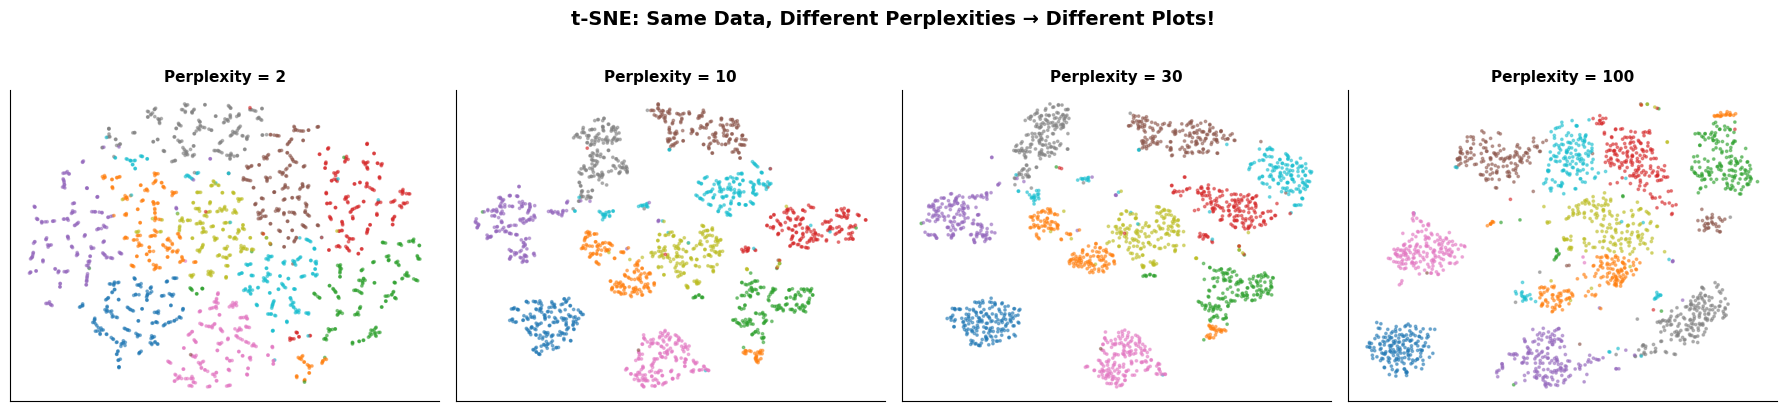

Perplexity too low (2): noise, meaningless micro-clusters.
Perplexity too high (100): structure washes out.
Sweet spot: usually 5-50, depending on dataset size.


In [16]:
# ── t-SNE instability: different perplexities ──

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, perp in zip(axes, [2, 10, 30, 100]):
    Z = TSNE(n_components=2, perplexity=perp, random_state=42,
             init='pca', learning_rate='auto').fit_transform(X_digits)
    ax.scatter(Z[:, 0], Z[:, 1], c=digits.target, cmap='tab10', s=3, alpha=0.5)
    ax.set_title(f'Perplexity = {perp}', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('t-SNE: Same Data, Different Perplexities → Different Plots!',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Perplexity too low (2): noise, meaningless micro-clusters.')
print('Perplexity too high (100): structure washes out.')
print('Sweet spot: usually 5-50, depending on dataset size.')


---
# Part 6: UMAP (Uniform Manifold Approximation and Projection)
---

## 6.1 The Idea

UMAP is similar to t-SNE in spirit (preserve neighborhoods) but has important advantages:

| | t-SNE | UMAP |
|---|---|---|
| **Speed** | Slow ($O(n^2)$ naive, $O(n\log n)$ Barnes-Hut) | Faster (graph-based) |
| **Global structure** | Poorly preserved | Better preserved |
| **New data** | Cannot transform new points | Has `.transform()` |
| **Dimensions** | Usually 2-3 | Any (can do 10, 50, etc.) |
| **Theory** | KL divergence on probabilities | Riemannian geometry + fuzzy topology |

## 6.2 How UMAP Works (Simplified)

1. **Build a weighted k-nearest-neighbor graph** in high dimensions. Edge weights reflect distance.
2. **Construct a fuzzy simplicial set** — a smooth approximation of the neighborhood structure.
3. **Optimize a low-dimensional layout** to have a similar fuzzy simplicial set (minimize cross-entropy between the two).

Key parameters:
- `n_neighbors`: Similar to perplexity in t-SNE. Controls local vs global balance.
- `min_dist`: Minimum distance between points in embedding. Smaller = tighter clusters.
- `metric`: Distance metric (Euclidean, cosine, etc.).

UMAP not installed. Install with: pip install umap-learn
Showing t-SNE only for comparison.



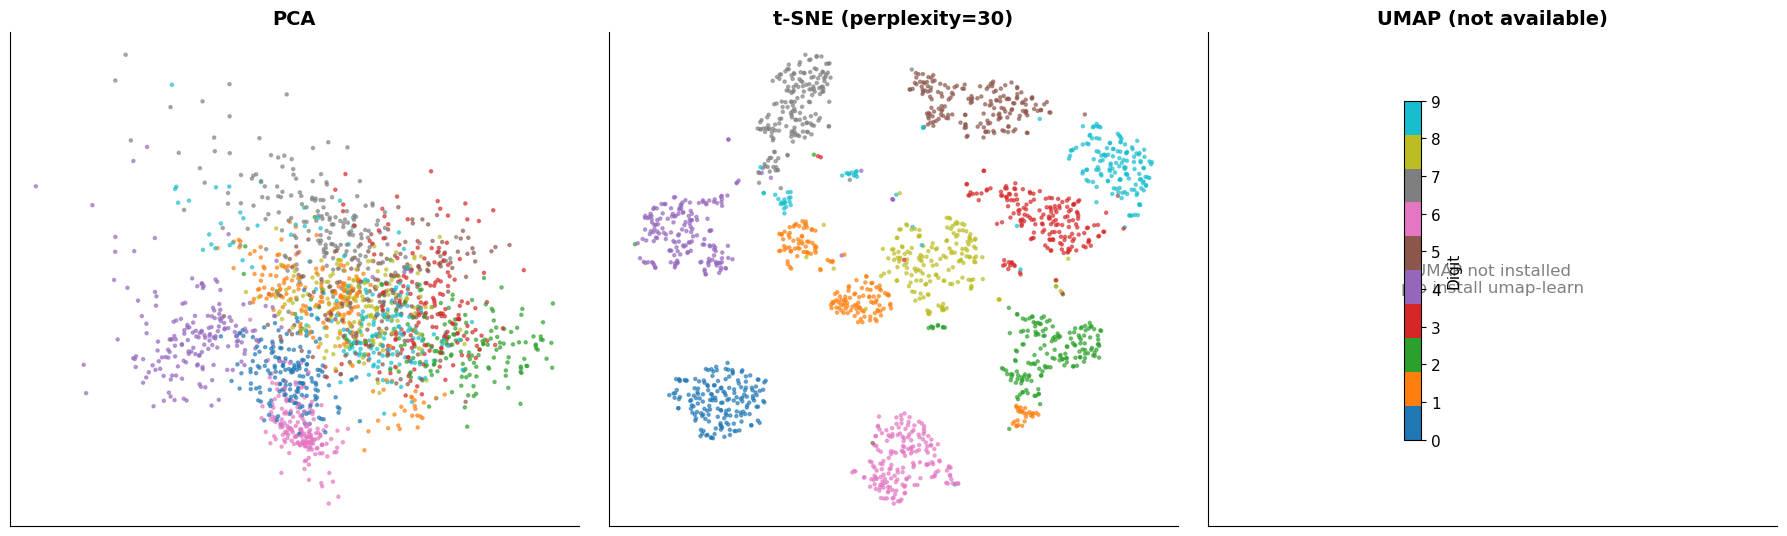

PCA: linear, fast, but clusters overlap.
t-SNE: great local structure, but slow and no transform.
UMAP: similar quality to t-SNE, but faster and supports transform.


In [17]:
# ── UMAP vs t-SNE comparison ──

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('UMAP not installed. Install with: pip install umap-learn')
    print('Showing t-SNE only for comparison.\n')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# PCA
ax = axes[0]
Z_pca_d = PCA(n_components=2).fit_transform(X_digits)
ax.scatter(Z_pca_d[:, 0], Z_pca_d[:, 1], c=digits.target, cmap='tab10', s=5, alpha=0.6)
ax.set_title('PCA')
ax.set_xticks([])
ax.set_yticks([])

# t-SNE
ax = axes[1]
Z_tsne_d = TSNE(n_components=2, perplexity=30, random_state=42,
                init='pca', learning_rate='auto').fit_transform(X_digits)
ax.scatter(Z_tsne_d[:, 0], Z_tsne_d[:, 1], c=digits.target, cmap='tab10', s=5, alpha=0.6)
ax.set_title('t-SNE (perplexity=30)')
ax.set_xticks([])
ax.set_yticks([])

# UMAP
ax = axes[2]
if HAS_UMAP:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    Z_umap_d = reducer.fit_transform(X_digits)
    ax.scatter(Z_umap_d[:, 0], Z_umap_d[:, 1], c=digits.target, cmap='tab10', s=5, alpha=0.6)
    ax.set_title('UMAP (n_neighbors=15)')
else:
    ax.text(0.5, 0.5, 'UMAP not installed\npip install umap-learn',
            ha='center', va='center', transform=ax.transAxes, fontsize=12, color='gray')
    ax.set_title('UMAP (not available)')
ax.set_xticks([])
ax.set_yticks([])

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap='tab10', norm=plt.Normalize(0, 9))
cbar = plt.colorbar(sm, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('Digit')
cbar.set_ticks(range(10))

plt.tight_layout()
plt.show()

print('PCA: linear, fast, but clusters overlap.')
print('t-SNE: great local structure, but slow and no transform.')
print('UMAP: similar quality to t-SNE, but faster and supports transform.')

---
# Part 7: Complete Comparison
---

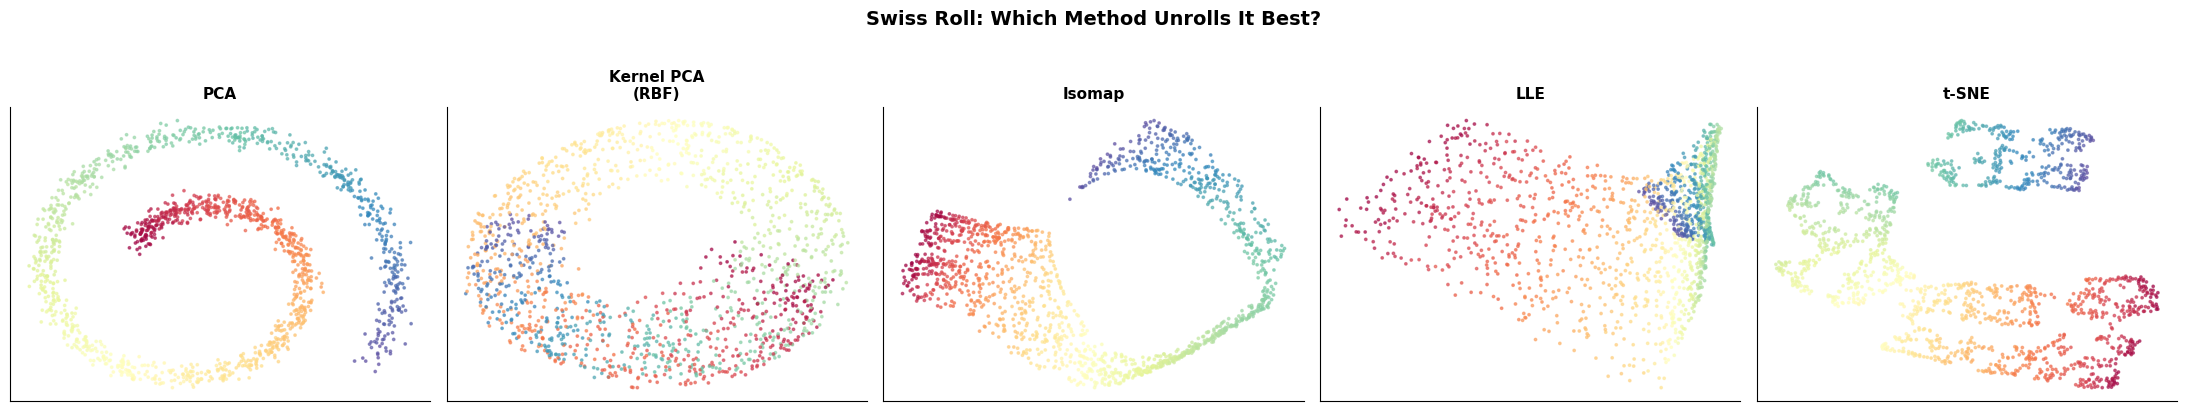

PCA: just squashes (linear method, can't unroll).
Kernel PCA: better but still struggles with the roll.
Isomap: uses geodesic distances → unrolls well!
LLE: preserves local linear structure → decent unrolling.
t-SNE: preserves local neighborhoods → good clusters but no global layout.


In [18]:
# ── All methods on the Swiss Roll ──

from sklearn.manifold import Isomap, LocallyLinearEmbedding

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

methods = [
    ('PCA', PCA(n_components=2)),
    ('Kernel PCA\n(RBF)', KernelPCA(n_components=2, kernel='rbf', gamma=0.01)),
    ('Isomap', Isomap(n_components=2, n_neighbors=12)),
    ('LLE', LocallyLinearEmbedding(n_components=2, n_neighbors=12)),
    ('t-SNE', TSNE(n_components=2, perplexity=30, random_state=42,
                   init='pca', learning_rate='auto')),
]

for ax, (name, method) in zip(axes, methods):
    Z = method.fit_transform(X_swiss)
    ax.scatter(Z[:, 0], Z[:, 1], c=color_swiss, cmap='Spectral', s=3, alpha=0.6)
    ax.set_title(name, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Swiss Roll: Which Method Unrolls It Best?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('PCA: just squashes (linear method, can\'t unroll).')
print('Kernel PCA: better but still struggles with the roll.')
print('Isomap: uses geodesic distances → unrolls well!')
print('LLE: preserves local linear structure → decent unrolling.')
print('t-SNE: preserves local neighborhoods → good clusters but no global layout.')

In [19]:
# ── Speed comparison ──

import time
from sklearn.datasets import make_classification

X_speed, _ = make_classification(n_samples=3000, n_features=50, random_state=42)

methods_speed = [
    ('PCA', PCA(n_components=2)),
    ('Kernel PCA (RBF)', KernelPCA(n_components=2, kernel='rbf')),
    ('Isomap', Isomap(n_components=2)),
    ('LLE', LocallyLinearEmbedding(n_components=2)),
    ('t-SNE', TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')),
]

timing_results = []
for name, method in methods_speed:
    start = time.time()
    method.fit_transform(X_speed)
    elapsed = time.time() - start
    timing_results.append({'Method': name, 'Time (s)': f'{elapsed:.3f}'})

print(pd.DataFrame(timing_results).to_string(index=False))
print('\nPCA is by far the fastest. t-SNE is the slowest.')
print('For large datasets: use PCA first to reduce to ~50 dims, THEN t-SNE/UMAP.')

          Method Time (s)
             PCA    0.004
Kernel PCA (RBF)    0.440
          Isomap    6.330
             LLE    2.962
           t-SNE   22.026

PCA is by far the fastest. t-SNE is the slowest.
For large datasets: use PCA first to reduce to ~50 dims, THEN t-SNE/UMAP.


---
# Part 8: When to Use Which?
---

## Quick Decision Guide

| Scenario | Best Choice | Why |
|---|---|---|
| Preprocessing for ML model | **PCA** | Fast, linear, invertible, works in pipelines |
| Visualization (2D/3D) | **t-SNE or UMAP** | Preserves local structure, beautiful clusters |
| Supervised preprocessing | **LDA** | Uses labels, maximizes class separation |
| Nonlinear features for ML | **Kernel PCA** | Captures nonlinear structure |
| Large dataset visualization | **UMAP** | Much faster than t-SNE, has transform |
| Remove multicollinearity | **PCA** | Components are orthogonal by construction |
| Noise reduction | **PCA** | Drop low-variance PCs (mostly noise) |
| Feature interpretation | **PCA** (with loadings) | Loadings show feature contributions |

## Common Interview Questions & Answers

**Q: What does PCA maximize?**
A: Variance of the projected data. Equivalently, it minimizes reconstruction error (MSE between original and reconstructed data).

**Q: Are principal components correlated?**
A: No! They are orthogonal (uncorrelated) by construction. The covariance matrix of the transformed data is diagonal.

**Q: Do you need to scale before PCA?**
A: Almost always yes. PCA maximizes variance, so features with larger scales dominate unless standardized.

**Q: PCA vs LDA?**
A: PCA is unsupervised (max variance). LDA is supervised (max class separation). LDA needs labels and is limited to K-1 components. Use LDA when you have labels and the goal is classification.

**Q: Can you use t-SNE for feature engineering?**
A: Not recommended. t-SNE has no transform for new data, is non-deterministic, and the embedding axes have no meaning. It's for visualization only.

**Q: What does perplexity do in t-SNE?**
A: It controls the effective number of neighbors each point considers. Low perplexity = local structure. High perplexity = global structure. Typical range: 5-50.

**Q: t-SNE vs UMAP?**
A: UMAP is faster, preserves global structure better, and supports transforming new data. t-SNE is older and more established but slower. For most use cases, prefer UMAP.

**Q: What is the relationship between PCA and SVD?**
A: PCA can be computed via SVD of the centered data matrix. The right singular vectors are the principal components, and the squared singular values (divided by n-1) are the eigenvalues of the covariance matrix. SVD is numerically more stable.

**Q: Can PCA handle nonlinear relationships?**
A: No. Standard PCA only captures linear correlations. Use Kernel PCA, t-SNE, or UMAP for nonlinear data.

**Q: How does PCA relate to reconstruction error?**
A: Maximizing variance of projections is mathematically equivalent to minimizing reconstruction error. The dropped components contribute the least to reconstruction.

---

## Summary Diagram

```
              DIMENSIONALITY REDUCTION
              ┌──────────┴──────────┐
           LINEAR                NONLINEAR
              │                     │
       ┌──────┴──────┐       ┌──────┴──────┐
  Unsupervised  Supervised  Neighbor-based  Kernel-based
       │           │           │                │
      PCA         LDA      ┌──┴──┐        Kernel PCA
                           │     │
                         t-SNE  UMAP
                     (visualization only)
```

---

**You're now equipped to:**
1. Derive PCA from scratch (covariance → eigendecomposition → projection)
2. Explain PCA via SVD and why sklearn uses it
3. Know when scaling matters and how to choose the number of components
4. Compare PCA vs LDA (unsupervised vs supervised, variance vs separability)
5. Explain t-SNE's math (probabilities, KL divergence, crowding problem)
6. Know t-SNE's pitfalls (cluster sizes, distances, no transform)
7. Explain UMAP advantages over t-SNE
8. Choose the right method for any scenario